# Analyse du benchmark — comparaison modèle vs annotateur expert

Ce notebook produit l'évaluation complète d'un run :

| § | Analyse | Question à laquelle elle répond |
|---|---------|--------------------------------|
| 1 | Synthèse globale + IC bootstrap | Quelle est la performance, avec quelle incertitude ? |
| 2 | Décomposition des désaccords | Le modèle sur-corrige-t-il ou sur-détecte-t-il ? |
| 3 | Accord par item (IC Wilson) | Quels mots posent problème ? |
| 4 | Précision/rappel de détection d'erreur par item | Où le modèle rate-t-il les fautes ? |
| 5 | Prévalence d'erreur : expert vs modèle | Le modèle biaise-t-il les statistiques finales ? |
| 6 | Analyse par copie | Les élèves faibles sont-ils plus durs à coder ? |
| 7 | Calibration de la confiance (ECE) | Peut-on se fier au score de confiance ? |
| 8 | Courbe de renvoi humain | Quel seuil opérationnel choisir ? |
| 9 | Matrices de confusion | Vue d'ensemble des transitions |
| 10 | Exports CSV | Données pour Excel / R / rapport |

**Prérequis** : un run terminé, ayant produit `data/processed/<RUN_NAME>_predictions.jsonl`.

**Note méthodologique** : les intervalles de confiance globaux utilisent un *bootstrap par grappes*
(rééchantillonnage des copies, pas des items) car les 83 items d'une même copie ne sont pas
indépendants — même élève, même écriture. Un bootstrap naïf sous-estimerait l'incertitude.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score

from evaluation_dictee.data.reference import load_grid
from evaluation_dictee.evaluation.calibration import (
    expected_calibration_error,
    referral_curve,
    reliability_bins,
)
from evaluation_dictee.evaluation.report import (
    confusion_df,
    disagreement_decomposition,
    load_predictions,
    per_copy_metrics,
    per_item_metrics,
)
from evaluation_dictee.evaluation.statistics import cluster_bootstrap

# ════════════════ PARAMÈTRES ════════════════
RUN_NAME = "dictee_gemma4_cot"   # ← nom du run à analyser
N_BOOT = 1000                          # 1000 = rigoureux, 200 = rapide pour itérer
# ════════════════════════════════════════════

BASE = Path("..")  # notebook lancé depuis notebooks/
PRED_PATH = BASE / f"data/processed/{RUN_NAME}_predictions.jsonl"
FIG_DIR = BASE / f"data/processed/figures_{RUN_NAME}"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 10,
})
C_OK, C_MOYEN, C_PB = "#2e7d32", "#ef6c00", "#c62828"
C_EXPERT, C_MODELE = "#1565c0", "#ef6c00"

df = load_predictions(PRED_PATH)
grid = load_grid(BASE / "configs/grille_dictee_2015.json")
id_to_mot = {it.item_id: it.attendu for it in grid.items}
id_to_type = {it.item_id: it.type for it in grid.items}
df["mot"] = df["item_id"].map(id_to_mot)

def lib(item_id: str) -> str:
    """Étiquette lisible : n° d'item + mot attendu."""
    return f"{item_id[-3:]} · {id_to_mot.get(item_id, '?')}"

print(f"Run     : {RUN_NAME}")
print(f"Copies  : {df['copy_id'].nunique():,}")
print(f"Items   : {df['item_id'].nunique()}")
print(f"Lignes  : {len(df):,}")

Run     : dictee_gemma4_cot
Copies  : 10
Items   : 83
Lignes  : 830


## 1. Synthèse globale avec intervalles de confiance

Le **rappel** (sensibilité) répond à : *« parmi les fautes vues par l'expert, combien le modèle en
retrouve-t-il ? »* — métrique clé pour la DEPP, car une faute manquée fausse la statistique nationale.
L'accord brut, lui, est gonflé mécaniquement par la prévalence du code « 1 » (~80 % des items).

In [2]:
def _accord(d):
    return float((d["y_true"] == d["y_pred"]).mean())

def _kappa(d):
    return float(cohen_kappa_score(d["y_true"], d["y_pred"]))

def _rappel(d):
    err = d[d["y_true"] != "1"]
    return float((err["y_pred"] != "1").mean()) if len(err) else float("nan")

def _precision(d):
    pred_err = d[d["y_pred"] != "1"]
    return float((pred_err["y_true"] != "1").mean()) if len(pred_err) else float("nan")

metriques = {
    "Accord brut": _accord,
    "Kappa de Cohen": _kappa,
    "Rappel erreurs (sensibilité)": _rappel,
    "Précision erreurs": _precision,
}

lignes = []
for nom, fn in metriques.items():
    ci = cluster_bootstrap(df, fn, n_boot=N_BOOT)
    lignes.append({"Métrique": nom, "Valeur": ci.estimate,
                   "IC95 bas": ci.lower, "IC95 haut": ci.upper})
synthese = pd.DataFrame(lignes).set_index("Métrique")

ece = expected_calibration_error(df["y_true"].tolist(), df["y_pred"].tolist(), df["confidence"].tolist())

display(synthese.style.format("{:.3f}")
        .set_caption(f"Métriques globales — {RUN_NAME} (IC bootstrap par copie, n_boot={N_BOOT})"))
prevalence = (df["y_true"] != "1").mean()
print(f"ECE (calibration de la confiance) : {ece:.3f}  — interprétation au §7")
print(f"Prévalence d'erreur (expert)      : {prevalence:.1%} — référence pour lire l'accord brut")

,Valeur,IC95 bas,IC95 haut
Métrique,,,
Accord brut,0.829,0.775,0.882
Kappa de Cohen,0.517,0.419,0.598
Rappel erreurs (sensibilité),0.652,0.512,0.769
Précision erreurs,0.624,0.517,0.708


ECE (calibration de la confiance) : 0.162  — interprétation au §7
Prévalence d'erreur (expert)      : 21.8% — référence pour lire l'accord brut


## 2. Décomposition des désaccords

Tous les désaccords ne se valent pas :
- **Sur-correction** (`expert:9 → modèle:1`) : le modèle lit le bon mot à la place de la faute →
  **sous-estime** les difficultés des élèves. Biais VLM documenté dans la note de cadrage.
- **Sur-détection** (`expert:1 → modèle:9`) : le modèle invente une faute → **surestime** les difficultés.

Les deux se compensent dans l'accord global mais déforment la statistique finale en sens opposés.

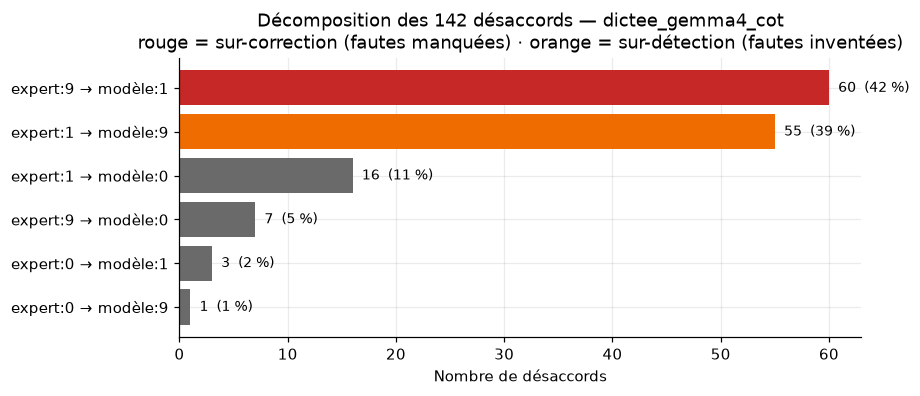

Sur-correction : 34.3% des fautes expert sont manquées
Ratio sur-correction / sur-détection : 60/55 → le modèle penche vers la sur-correction


In [3]:
deco = disagreement_decomposition(df)
n_dis = deco["n"].sum()

fig, ax = plt.subplots(figsize=(8, max(2.4, 0.55 * len(deco))))
couleurs = [C_PB if "9 → modèle:1" in t else C_MOYEN if "1 → modèle:9" in t else "#6a6a6a"
            for t in deco["transition"]]
bars = ax.barh(deco["transition"], deco["n"], color=couleurs)
for b, n, pct in zip(bars, deco["n"], deco["pct_desaccords"]):
    ax.text(b.get_width() + n_dis * 0.006, b.get_y() + b.get_height() / 2,
            f"{n}  ({pct:.0f} %)", va="center", fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Nombre de désaccords")
ax.set_title(f"Décomposition des {n_dis:,} désaccords — {RUN_NAME}\n"
             "rouge = sur-correction (fautes manquées) · orange = sur-détection (fautes inventées)")
plt.savefig(FIG_DIR / "02_decomposition_desaccords.png")
plt.show()

sur_corr = deco.loc[deco["transition"].str.contains("9 → modèle:1"), "n"].sum()
sur_det = deco.loc[deco["transition"].str.contains("1 → modèle:9"), "n"].sum()
n_err_expert = (df["y_true"] == "9").sum()
print(f"Sur-correction : {sur_corr / max(n_err_expert, 1):.1%} des fautes expert sont manquées")
tendance = "sur-correction" if sur_corr > sur_det else "sur-détection"
print(f"Ratio sur-correction / sur-détection : {sur_corr}/{sur_det} → le modèle penche vers la {tendance}")

## 3. Accord par item, avec intervalles de Wilson

Chaque barre porte son IC 95 % : 90 % d'accord sur 50 copies est bien moins certain que sur 3 000.
Trié du plus problématique au meilleur.

/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in

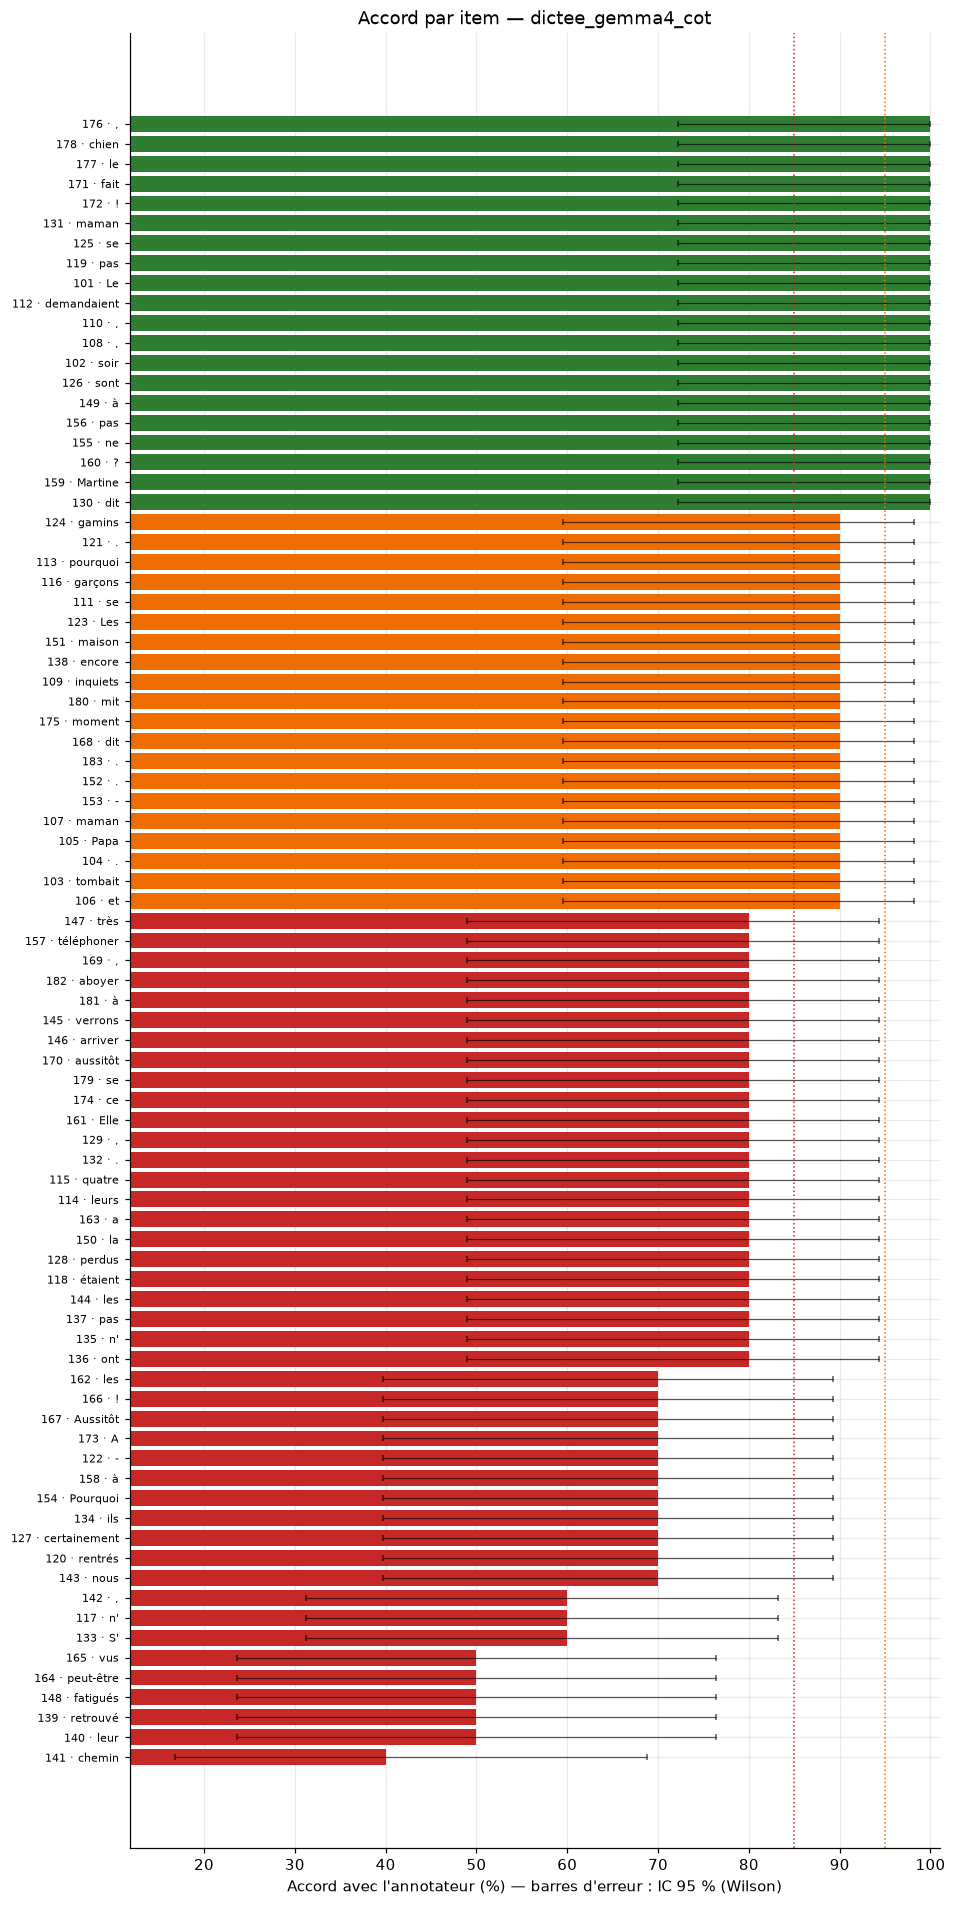

Items sous 90 % d'accord :


,n,accord,accord_lo,accord_hi,pct_erreur_expert
141 · chemin,10,40.0%,16.8%,68.7%,60 %
140 · leur,10,50.0%,23.7%,76.3%,40 %
139 · retrouvé,10,50.0%,23.7%,76.3%,60 %
148 · fatigués,10,50.0%,23.7%,76.3%,60 %
164 · peut-être,10,50.0%,23.7%,76.3%,40 %
165 · vus,10,50.0%,23.7%,76.3%,100 %
133 · S',10,60.0%,31.3%,83.2%,50 %
117 · n',10,60.0%,31.3%,83.2%,0 %
"142 · ,",10,60.0%,31.3%,83.2%,0 %
143 · nous,10,70.0%,39.7%,89.2%,10 %


In [4]:
items = per_item_metrics(df)
items_tries = items.sort_values("accord")

fig, ax = plt.subplots(figsize=(9.5, 0.24 * len(items_tries) + 1.5))
y = np.arange(len(items_tries))
couleurs = [C_PB if v < 0.85 else C_MOYEN if v < 0.95 else C_OK for v in items_tries["accord"]]
err_low = (items_tries["accord"] - items_tries["accord_lo"]) * 100
err_high = (items_tries["accord_hi"] - items_tries["accord"]) * 100
ax.barh(y, items_tries["accord"] * 100, xerr=[err_low, err_high],
        color=couleurs, error_kw={"lw": 0.8, "capsize": 2, "alpha": 0.65})
ax.set_yticks(y)
ax.set_yticklabels([lib(i) for i in items_tries.index], fontsize=7)
ax.axvline(85, color=C_PB, ls=":", lw=1)
ax.axvline(95, color=C_MOYEN, ls=":", lw=1)
ax.set_xlim(max(0, items_tries["accord_lo"].min() * 100 - 5), 101)
ax.set_xlabel("Accord avec l'annotateur (%) — barres d'erreur : IC 95 % (Wilson)")
ax.set_title(f"Accord par item — {RUN_NAME}")
plt.savefig(FIG_DIR / "03_accord_par_item.png")
plt.show()

print("Items sous 90 % d'accord :")
pires = items_tries[items_tries["accord"] < 0.90]
if len(pires):
    aff = pires[["n", "accord", "accord_lo", "accord_hi", "pct_erreur_expert"]].copy()
    aff.index = [lib(i) for i in aff.index]
    display(aff.style.format({"accord": "{:.1%}", "accord_lo": "{:.1%}",
                              "accord_hi": "{:.1%}", "pct_erreur_expert": "{:.0f} %"}))
else:
    print("  aucun — tous les items sont ≥ 90 %")

## 4. Qualité de détection d'erreur par item : précision vs rappel

L'accord brut est trompeur sur les items où presque tout le monde écrit juste (accord élevé même si
le modèle rate toutes les rares fautes). Ce nuage ne regarde **que la détection des fautes** :
- **Rappel** (x) : part des fautes de l'expert retrouvées par le modèle.
- **Précision** (y) : part des fautes signalées par le modèle confirmées par l'expert.

L'idéal est en haut à droite. En bas à droite : sur-détection. En haut à gauche : sur-correction.
Seuls les items avec au moins 3 % de fautes sont affichés (sinon non significatif).

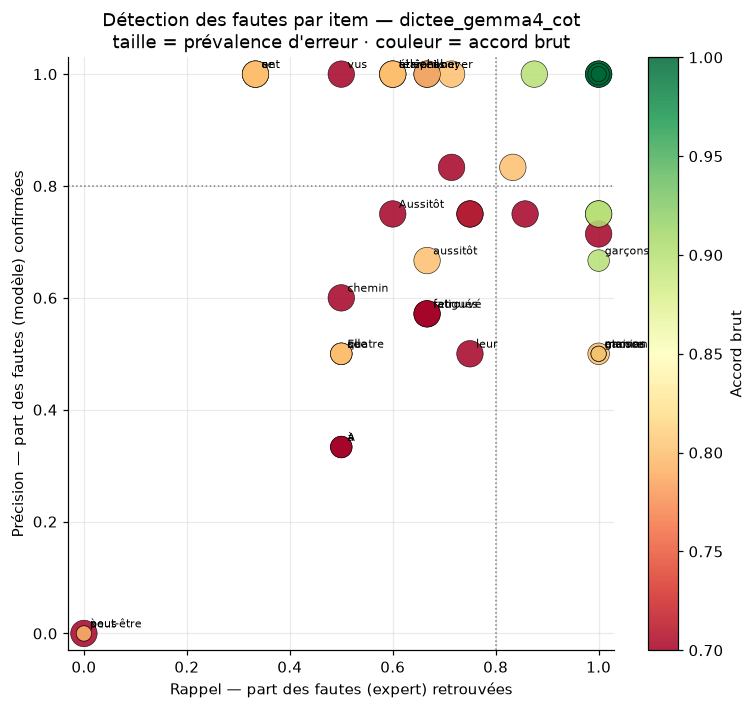

In [5]:
det = items.dropna(subset=["rappel_erreur", "precision_erreur"]).copy()
det = det[det["pct_erreur_expert"] >= 3]

fig, ax = plt.subplots(figsize=(8, 7))
taille = np.clip(det["pct_erreur_expert"] * 10, 20, 300)
sc = ax.scatter(det["rappel_erreur"], det["precision_erreur"], s=taille,
                c=det["accord"], cmap="RdYlGn", vmin=0.7, vmax=1.0,
                edgecolors="k", linewidths=0.4, alpha=0.85)
for idx, row in det.iterrows():
    if row["rappel_erreur"] < 0.7 or row["precision_erreur"] < 0.7:
        ax.annotate(id_to_mot.get(idx, ""), (row["rappel_erreur"], row["precision_erreur"]),
                    fontsize=7.5, xytext=(4, 4), textcoords="offset points")
ax.axvline(0.8, color="grey", ls=":", lw=1)
ax.axhline(0.8, color="grey", ls=":", lw=1)
ax.set_xlabel("Rappel — part des fautes (expert) retrouvées")
ax.set_ylabel("Précision — part des fautes (modèle) confirmées")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.set_title(f"Détection des fautes par item — {RUN_NAME}\n"
             "taille = prévalence d'erreur · couleur = accord brut")
plt.colorbar(sc, label="Accord brut")
plt.savefig(FIG_DIR / "04_precision_rappel_items.png")
plt.show()

## 5. Le modèle biaise-t-il la statistique finale ?

La DEPP publie des **taux de réussite par mot**. Ce graphique compare la prévalence d'erreur mesurée
par l'expert (x) et par le modèle (y). Un point sous la diagonale = le modèle sous-estime la difficulté
de ce mot (sur-correction nette). C'est LE graphique qui dit si une production statistique automatisée
serait biaisée, et dans quel sens, mot par mot.

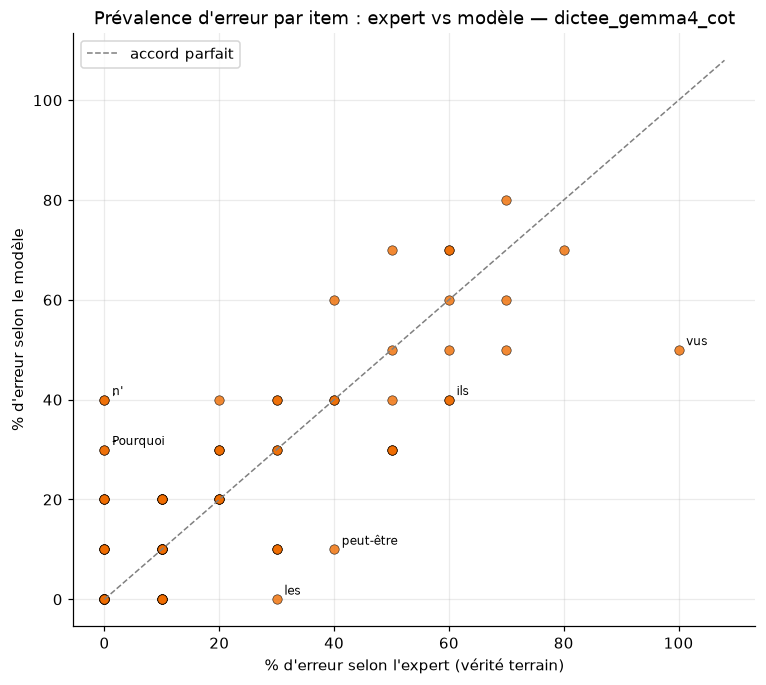

Biais moyen : +1.0 points de % → le modèle surestime les erreurs en moyenne


In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
maxv = max(items["pct_erreur_expert"].max(), items["pct_erreur_modele"].max()) * 1.08
ax.plot([0, maxv], [0, maxv], color="grey", ls="--", lw=1, label="accord parfait")
ax.scatter(items["pct_erreur_expert"], items["pct_erreur_modele"],
           s=38, alpha=0.8, color=C_MODELE, edgecolors="k", linewidths=0.4)
items["ecart"] = items["pct_erreur_modele"] - items["pct_erreur_expert"]
plus_gros = items["ecart"].abs().sort_values(ascending=False).index[:8]
for idx in plus_gros:
    row = items.loc[idx]
    ax.annotate(id_to_mot.get(idx, ""), (row["pct_erreur_expert"], row["pct_erreur_modele"]),
                fontsize=8, xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("% d'erreur selon l'expert (vérité terrain)")
ax.set_ylabel("% d'erreur selon le modèle")
ax.set_title(f"Prévalence d'erreur par item : expert vs modèle — {RUN_NAME}")
ax.legend()
plt.savefig(FIG_DIR / "05_prevalence_expert_vs_modele.png")
plt.show()

biais = items["ecart"].mean()
sens = "sous-estime" if biais < 0 else "surestime"
print(f"Biais moyen : {biais:+.1f} points de % → le modèle {sens} les erreurs en moyenne")

## 6. Analyse par copie : les élèves faibles sont-ils plus durs à coder ?

Constat du test pilote : la copie la plus fautive était la plus difficile. Si l'accord chute avec
le taux d'erreur de l'élève, le modèle est **moins fiable précisément là où l'enjeu est le plus
grand** — à surveiller pour tout usage opérationnel.

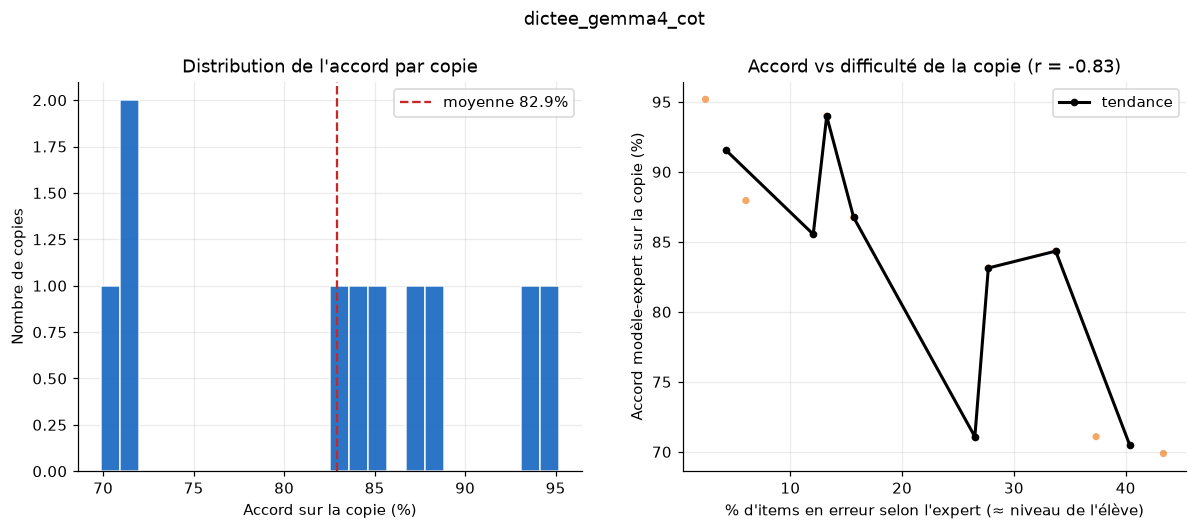


10 copies les plus mal codées (à inspecter visuellement) :


,n_items,accord,pct_erreur_expert,confiance_moyenne
copy_id,,,,
dictee_2015_0010.png,83,69.9%,43 %,1.00
dictee_2015_0004.png,83,71.1%,27 %,0.97
dictee_2015_0009.png,83,71.1%,37 %,0.97
dictee_2015_0006.png,83,83.1%,28 %,0.99
dictee_2015_0002.png,83,84.3%,34 %,1.00
dictee_2015_0001.png,83,85.5%,12 %,1.00
dictee_2015_0005.png,83,86.7%,16 %,1.00
dictee_2015_0003.png,83,88.0%,6 %,0.99
dictee_2015_0007.png,83,94.0%,13 %,1.00


In [7]:
copies = per_copy_metrics(df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

ax1.hist(copies["accord"] * 100, bins=24, color=C_EXPERT, edgecolor="white", alpha=0.9)
ax1.axvline(copies["accord"].mean() * 100, color=C_PB, ls="--",
            label=f"moyenne {copies['accord'].mean():.1%}")
ax1.set_xlabel("Accord sur la copie (%)")
ax1.set_ylabel("Nombre de copies")
ax1.set_title("Distribution de l'accord par copie")
ax1.legend()

ax2.scatter(copies["pct_erreur_expert"], copies["accord"] * 100,
            s=22, alpha=0.6, color=C_MODELE, edgecolors="none")
nq = min(8, copies["pct_erreur_expert"].nunique())
q = pd.qcut(copies["pct_erreur_expert"], q=nq, duplicates="drop")
tend = copies.groupby(q, observed=True).agg(x=("pct_erreur_expert", "mean"), yacc=("accord", "mean"))
ax2.plot(tend["x"], tend["yacc"] * 100, color="k", lw=2, marker="o", ms=4, label="tendance")
corr = copies["accord"].corr(copies["pct_erreur_expert"])
ax2.set_xlabel("% d'items en erreur selon l'expert (≈ niveau de l'élève)")
ax2.set_ylabel("Accord modèle-expert sur la copie (%)")
ax2.set_title(f"Accord vs difficulté de la copie (r = {corr:.2f})")
ax2.legend()

plt.suptitle(RUN_NAME, y=1.02)
plt.savefig(FIG_DIR / "06_analyse_par_copie.png")
plt.show()

print("\n10 copies les plus mal codées (à inspecter visuellement) :")
aff = copies.sort_values("accord").head(10)
display(aff.style.format({"accord": "{:.1%}", "pct_erreur_expert": "{:.0f} %",
                          "confiance_moyenne": "{:.2f}"}))

## 7. Calibration de la confiance

Le renvoi humain ciblé (§8) ne fonctionne que si le score de confiance est honnête. Sur le diagramme
de fiabilité, un modèle calibré suit la diagonale : « quand il annonce 0,9, il a raison 9 fois sur 10 ».

Lecture de l'**ECE** : < 0,05 bon · 0,05–0,10 acceptable · > 0,10 recalibrer avant usage.

Le panneau de droite vérifie le pouvoir **discriminant** : si les distributions juste/faux se
superposent, la confiance ne sert à rien même bien calibrée.

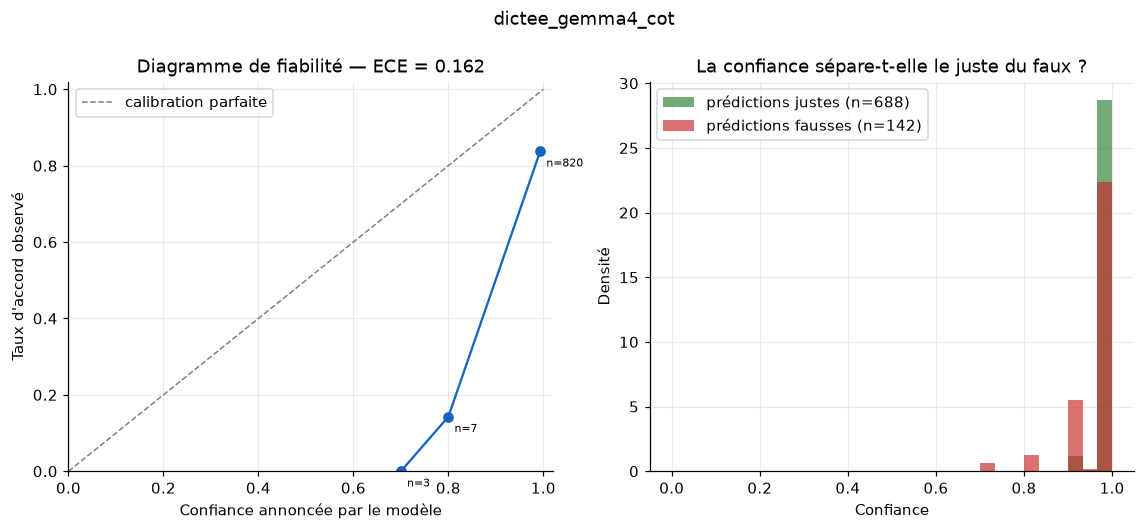

In [8]:
bins = reliability_bins(df["y_true"].tolist(), df["y_pred"].tolist(),
                        df["confidence"].tolist(), n_bins=10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

xs = [b.mean_confidence for b in bins]
ys = [b.accuracy for b in bins]
ns = [b.n for b in bins]
ax1.plot([0, 1], [0, 1], "--", color="grey", lw=1, label="calibration parfaite")
ax1.plot(xs, ys, "-o", color=C_EXPERT, ms=6)
for x, y_, n in zip(xs, ys, ns):
    ax1.annotate(f"n={n}", (x, y_), fontsize=7, xytext=(4, -10), textcoords="offset points")
ax1.set_xlabel("Confiance annoncée par le modèle")
ax1.set_ylabel("Taux d'accord observé")
ax1.set_xlim(0, 1.02)
ax1.set_ylim(0, 1.02)
ax1.set_title(f"Diagramme de fiabilité — ECE = {ece:.3f}")
ax1.legend(loc="upper left")

ok = df[df["y_true"] == df["y_pred"]]["confidence"].dropna()
ko = df[df["y_true"] != df["y_pred"]]["confidence"].dropna()
bins_h = np.linspace(0, 1, 31)
ax2.hist(ok, bins=bins_h, alpha=0.65, label=f"prédictions justes (n={len(ok):,})",
         color=C_OK, density=True)
ax2.hist(ko, bins=bins_h, alpha=0.65, label=f"prédictions fausses (n={len(ko):,})",
         color=C_PB, density=True)
ax2.set_xlabel("Confiance")
ax2.set_ylabel("Densité")
ax2.set_title("La confiance sépare-t-elle le juste du faux ?")
ax2.legend()

plt.suptitle(RUN_NAME, y=1.02)
plt.savefig(FIG_DIR / "07_calibration.png")
plt.show()

## 8. Courbe de renvoi humain — le livrable décisionnel

Pour chaque seuil de confiance : la part d'items renvoyés à un correcteur humain (**coût**) et le
taux d'erreur résiduel sur les items auto-validés (**qualité**). Le point de fonctionnement se choisit
en fixant la qualité cible — ici on annote le plus petit renvoi atteignant **≤ 2 % d'erreur résiduelle**.

Aucun seuil n'atteint 2.0 % — modèle insuffisant pour cette cible.


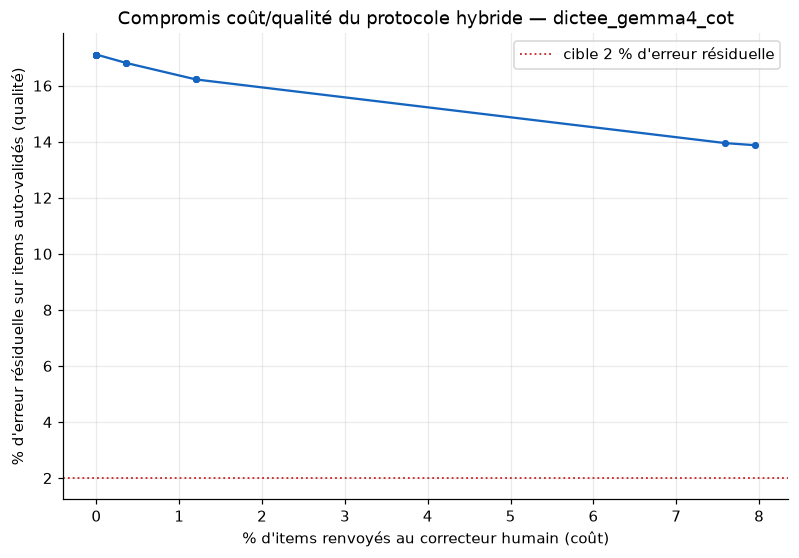

seuil,renvoi humain %,erreur résiduelle %,items auto-validés
0.00,0.0,17.11,830
0.10,0.0,17.11,830
0.20,0.0,17.11,830
0.30,0.0,17.11,830
0.40,0.0,17.11,830
0.50,0.0,17.11,830
0.60,0.0,17.11,830
0.70,0.0,17.11,830
0.80,0.4,16.81,827
0.90,1.2,16.22,820


In [9]:
points = referral_curve(df["y_true"].tolist(), df["y_pred"].tolist(),
                        df["confidence"].tolist(), thresholds=[i / 40 for i in range(41)])
renvoi = np.array([p.human_referral_rate for p in points]) * 100
residu = np.array([p.residual_error_rate for p in points]) * 100

CIBLE = 2.0  # % d'erreur résiduelle acceptable — à arbitrer avec la DEPP
ok_pts = [(p, r, e) for p, r, e in zip(points, renvoi, residu) if e <= CIBLE]
op = min(ok_pts, key=lambda t: t[1]) if ok_pts else None

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(renvoi, residu, "-o", ms=3.5, color=C_EXPERT)
ax.axhline(CIBLE, color=C_PB, ls=":", lw=1.2, label=f"cible {CIBLE:.0f} % d'erreur résiduelle")
if op:
    p, r, e = op
    ax.scatter([r], [e], s=130, color=C_PB, zorder=5, marker="*")
    ax.annotate(f"seuil {p.threshold:.2f}\nrenvoi {r:.0f} % · résidu {e:.1f} %",
                (r, e), xytext=(12, 14), textcoords="offset points", fontsize=9,
                arrowprops={"arrowstyle": "->", "lw": 0.8})
else:
    print(f"Aucun seuil n'atteint {CIBLE} % — modèle insuffisant pour cette cible.")
ax.set_xlabel("% d'items renvoyés au correcteur humain (coût)")
ax.set_ylabel("% d'erreur résiduelle sur items auto-validés (qualité)")
ax.set_title(f"Compromis coût/qualité du protocole hybride — {RUN_NAME}")
ax.legend()
plt.savefig(FIG_DIR / "08_courbe_renvoi.png")
plt.show()

tab = pd.DataFrame([{"seuil": p.threshold, "renvoi humain %": r, "erreur résiduelle %": e,
                     "items auto-validés": p.n_auto_validated}
                    for p, r, e in zip(points, renvoi, residu)])
display(tab.iloc[::4].style.format({"seuil": "{:.2f}", "renvoi humain %": "{:.1f}",
                                     "erreur résiduelle %": "{:.2f}"}).hide(axis="index")
        .set_caption("Points de fonctionnement (1 seuil sur 4 affiché)"))

## 9. Matrices de confusion : effectifs et normalisée

La version normalisée par ligne se lit : « parmi les items que l'expert a codés X, comment le modèle
les répartit-il ? ». Elle rend visibles les erreurs sur les classes rares (9 et 0), écrasées dans
la matrice brute par les ~80 % de codes « 1 ».

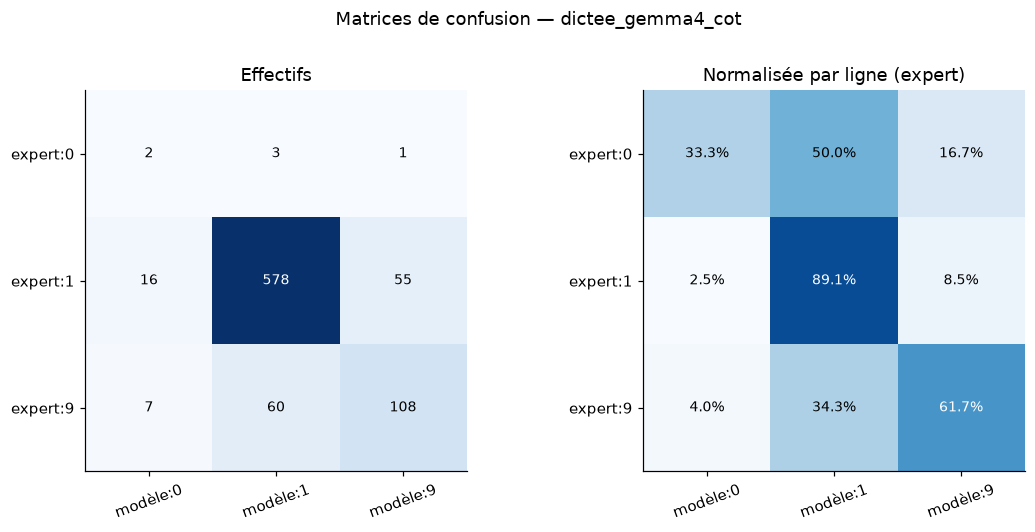

In [10]:
cm_raw = confusion_df(df)
cm_norm = confusion_df(df, normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, cm, titre, fmt in [(axes[0], cm_raw, "Effectifs", "{:,.0f}"),
                            (axes[1], cm_norm, "Normalisée par ligne (expert)", "{:.1%}")]:
    vals = cm.values.astype(float)
    ax.imshow(vals, cmap="Blues", vmax=vals.max() if titre == "Effectifs" else 1)
    ax.set_xticks(range(len(cm.columns)))
    ax.set_xticklabels(cm.columns, rotation=20)
    ax.set_yticks(range(len(cm.index)))
    ax.set_yticklabels(cm.index)
    seuil_blanc = vals.max() * 0.6
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, fmt.format(vals[i, j]), ha="center", va="center", fontsize=9,
                    color="white" if vals[i, j] > seuil_blanc else "black")
    ax.set_title(titre)
    ax.grid(False)
plt.suptitle(f"Matrices de confusion — {RUN_NAME}", y=1.04)
plt.savefig(FIG_DIR / "09_confusion.png")
plt.show()

## 10. Exports

Trois CSV (encodage `utf-8-sig`, séparateur `;`, décimale `,` → ouverture directe dans Excel
français) : métriques par item, par copie, et points de la courbe de renvoi. Toutes les figures
sont déjà enregistrées dans `data/processed/figures_<run>/`.

In [11]:
export_items = items.copy()
export_items.insert(0, "mot_attendu", [id_to_mot.get(i, "") for i in export_items.index])
export_items.insert(1, "type", [id_to_type.get(i, "") for i in export_items.index])

exports = {
    f"{RUN_NAME}_metriques_par_item.csv": export_items,
    f"{RUN_NAME}_metriques_par_copie.csv": copies,
    f"{RUN_NAME}_courbe_renvoi.csv": tab,
}
for nom, d in exports.items():
    chemin = BASE / "data/processed" / nom
    d.to_csv(chemin, sep=";", decimal=",", encoding="utf-8-sig")
    print(f"Exporté : {chemin}")
print(f"\nFigures : {FIG_DIR}")

Exporté : ../data/processed/dictee_gemma4_cot_metriques_par_item.csv
Exporté : ../data/processed/dictee_gemma4_cot_metriques_par_copie.csv
Exporté : ../data/processed/dictee_gemma4_cot_courbe_renvoi.csv

Figures : ../data/processed/figures_dictee_gemma4_cot
